In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("BotnetFull.csv")
df.shape

(3458, 456)

In [3]:
import pandas as pd

# Load your dataset
data = pd.read_csv("BotnetFull.csv")

# Find duplicated columns (True for duplicates, False for first occurrences)
duplicates_mask = data.T.duplicated()

# Get the list of duplicated column names
duplicated_columns = data.columns[duplicates_mask]

# Print duplicated columns
print(f"🛑 Duplicated columns:\n{duplicated_columns.tolist()}")

# Remove duplicated columns (keep first occurrence)
data = data.loc[:, ~duplicates_mask]

# Print updated shape
print(f"\n✅ Dataset shape after removing duplicate columns: {data.shape}")


🛑 Duplicated columns:
['write\nprofile', 'read\ncell\nbroadcasts', 'change\nwimax\nstate', 'add\nvoicemail', 'bind\ndirectory\nsearch', 'account\nmanager', 'master\nclear', 'send\nsms\nno\nconfirmation', 'configure\nwifi\ndisplay', 'allow\nany\ncodec\nfor\nplayback', 'BROADCAST\nPACKAGE\nINSTALL', 'BROADCAST\nPACKAGE\nREPLACED', 'control\nlocation\nupdates', 'BADGE\nCOUNT\nWRITE', 'ACCESS\nCONTENT\nPROVIDER', 'ACCESS\nPHOTO LAB', 'CLOUD\nPERMISSION', 'PERMISSION\nSTOP\nWATCHDOG\nAFTER\nSCREEN OFF', 'CLIPBOARDAVESERVICE\nPERMISSION', 'WRITE\nPERMISSION', 'CACHE\nPERMISSION', 'TEMPORARY\nDISABLE', 'READ\nCREDENTIALS', 'SET TIME ZONE', 'UPDATE\nCONFIG', 'APP\nHSP', 'SENSOR\nINFO', 'WRITE\nEPG\nDATA', 'WRITE\nCARD\nDATA', 'DUID\nREAD\nPROVIDER', 'CAPTURE\nAUDIO\nHOTWORD', 'GET\nSTATE', 'DRAW\nCROP', 'EDIT', 'PREFETCH', 'KEYSTRING', 'SAVE', 'RESTRICTED', 'AAM2', 'UBLS\nWRITE LOG', 'SECURE\nVIEW', 'HMS\nZERO', 'MEDIAMANAGER\nACCESS MM', 'USE SOCIAL\nSERVICE', 'FEATUREDB\nACCESS', 'READ\nCAME

In [4]:
from sklearn.model_selection import train_test_split
# Step 2: Separate features and labels (last column is label)
X = data.iloc[:, :-1]  # first 455 columns
y = data.iloc[:, -1]   # last column
# Step 4: Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [6]:
# Step 3: Apply Chi-Squared test
from sklearn.feature_selection import SelectKBest, chi2
selector = SelectKBest(score_func=chi2, k=50)  # Select top 50 features
X_selected = selector.fit_transform(X, y)

# Step 4: Get selected feature names
selected_columns = X.columns[selector.get_support()]
print("✅ Top 50 features selected using Chi-Squared test:")
print(selected_columns.tolist())
# Optional: Create DataFrame of selected features
X_selected_df = pd.DataFrame(X_selected, columns=selected_columns)

✅ Top 50 features selected using Chi-Squared test:
['read\nphone\nstate', 'c2d\nmessage', 'call\nphone', 'authenticate\naccounts', 'manage\naccounts', 'use\ncredentials', 'write\ncontacts', 'read\ncontacts', 'write\nsms', 'read\nsms', 'receive\nsms', 'send\nsms', 'read\nhistory\nbookmarks', 'write\nhistory\nbookmarks', 'read\ncall\nlog', 'write\ncall\nlog', 'process\noutgoing\ncalls', 'disable\nkeyguard', 'write\napn\nsettings', 'mount\nunmount\nfile\nsystems', 'modify\nphone\nstate', 'reboot', 'MODIFY\nAUDIO\nSETTINGS', 'FOREGROUND\nSERVICE', 'READ\nEXTERNAL\nSTORAGE', 'RECEIVE\nBOOT\nCOMPLETED', 'WAKE\nLOCK', 'BILLING', 'RECEIVE', 'BIND GET\nINSTALL\nREFERRER\nSERVICE', 'READ\nSETTINGS', 'READ\nG\nSERVICES', 'SET ALARM', 'SET\nWALLPAPER', 'REQUEST\nINSTALL\nPACKAGES', 'RESTART\nPACKAGES', 'UPDATE\nSHORTCUT', 'UPDATE\nCOUNT', 'READ\nAPP\nBADGE', 'CHANGE\nBADGE', 'UPDATE\nBADGE', 'READ', 'WRITE', 'BROADCAST\nBADGE', 'PROVIDER\nINSERT\nBADGE', 'BADGE\nCOUNT\nREAD', 'ACCESS\nGPS', 'ACCES

In [2]:
pip install keras-tuner --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 10.0 MB/s eta 0:00:00


In [6]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Activation, Dropout, LeakyReLU
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import keras_tuner as kt
# Step 1: Load and clean the dataset
df = pd.read_csv("BotnetFull.csv")

df.columns = df.columns.str.replace('\n', '', regex=True).str.strip()

# Step 2: remove duplicated columns
duplicates_mask = df.T.duplicated()
# Get the list of duplicated column names
duplicated_columns = df.columns[duplicates_mask]
# Print duplicated columns
print(f"🛑 Duplicated columns:\n{duplicated_columns.tolist()}")
# Remove duplicated columns (keep first occurrence)
df = df.loc[:, ~duplicates_mask]
# Print updated shape
print(f"\n✅ Dataset shape after removing duplicate columns: {df.shape}")


# Step 3: Split features and label (last column is label)
df = pd.read_csv("BotnetFull.csv")
X = df.iloc[:, :-1].values  # First 455 columns = features
y = df.iloc[:, -1].values   # Last column = label (0 or 1)

def build_model(hp):
    model = Sequential()

    # First hidden layer
    model.add(Dense(
        hp.Int('units_0', min_value=16, max_value=64, step=16),
        input_shape=(50,),
        use_bias=False,
        kernel_regularizer=l2(hp.Float('l2_reg', 1e-4, 1e-2, sampling='log'))
    ))
    model.add(BatchNormalization())

    # Choose activation: relu or leaky_relu
    activation_choice = hp.Choice('activation', ['relu'])
    if activation_choice == 'relu':
        model.add(Activation('relu'))
    else:
        model.add(LeakyReLU(alpha=0.01))

    model.add(Dropout(hp.Float('dropout_rate_0', 0.2, 0.3, step=0.1)))

    # Additional hidden layers
    for i in range(hp.Int('num_hidden_layers', 1, 2)):
        model.add(Dense(
            hp.Int(f'units_{i+1}', min_value=8, max_value=32, step=8),
            use_bias=False,
            kernel_regularizer=l2(hp.Float(f'l2_reg_{i+1}', 1e-4, 1e-2, sampling='log'))
        ))
        model.add(BatchNormalization())
        if activation_choice == 'relu':
            model.add(Activation('relu'))
        else:
            model.add(LeakyReLU(alpha=0.01))
        model.add(Dropout(hp.Float(f'dropout_rate_{i+1}', 0.3, 0.4, step=0.1)))

    # Output layer
    model.add(Dense(1, activation='sigmoid', kernel_regularizer=l2(0.001)))

    # Choose optimizer
    optimizer_choice = hp.Choice('optimizer', ['adam'])
    model.compile(optimizer=optimizer_choice, loss='binary_crossentropy', metrics=['accuracy'])

    return model

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Reduce learning rate when stuck
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-6)

# Train-test split properly
from sklearn.model_selection import train_test_split

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=22, stratify=y
)
#Step 4: do varaince threshold
from sklearn.feature_selection import VarianceThreshold
sel = VarianceThreshold(threshold=0.01)
X_train_full = sel.fit_transform(X_train_full)
X_test = sel.transform(X_test)

#Step 5: do chi-squared test
from sklearn.feature_selection import SelectKBest, chi2
selector = SelectKBest(score_func=chi2, k=50)  # Select top 50 features
X_train_full = selector.fit_transform(X_train_full, y_train_full)
X_test = selector.transform(X_test)
print("after chi-squared test, X_train shape:",X_train_full.shape)
print("after chi-squared test, X_test shape:",X_test.shape)
# Create tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=20,
    directory='tuner_dir',
    project_name='botnet_tuning'
)

# Search including batch size tuning
tuner.search(
    X_train_full, y_train_full,
    epochs=100,
    validation_split=0.2,
    batch_size=kt.HyperParameters().Choice('batch_size', [16, 32, 64, 128]),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Evaluate best model
best_model = tuner.get_best_models(num_models=1)[0]
test_loss, test_acc = best_model.evaluate(X_test, y_test, verbose=0)
print(f"\n✅ Test Accuracy of best model: {test_acc * 100:.2f}%")


🛑 Duplicated columns:
['writeprofile', 'readcellbroadcasts', 'changewimaxstate', 'addvoicemail', 'binddirectorysearch', 'accountmanager', 'masterclear', 'sendsmsnoconfirmation', 'configurewifidisplay', 'allowanycodecforplayback', 'BROADCASTPACKAGEINSTALL', 'BROADCASTPACKAGEREPLACED', 'controllocationupdates', 'BADGECOUNTWRITE', 'ACCESSCONTENTPROVIDER', 'ACCESSPHOTO LAB', 'CLOUDPERMISSION', 'PERMISSIONSTOPWATCHDOGAFTERSCREEN OFF', 'CLIPBOARDAVESERVICEPERMISSION', 'WRITEPERMISSION', 'CACHEPERMISSION', 'TEMPORARYDISABLE', 'READCREDENTIALS', 'SET TIME ZONE', 'UPDATECONFIG', 'APPHSP', 'SENSORINFO', 'WRITEEPGDATA', 'WRITECARDDATA', 'DUIDREADPROVIDER', 'CAPTUREAUDIOHOTWORD', 'GETSTATE', 'DRAWCROP', 'EDIT', 'PREFETCH', 'KEYSTRING', 'SAVE', 'RESTRICTED', 'AAM2', 'UBLSWRITE LOG', 'SECUREVIEW', 'HMSZERO', 'MEDIAMANAGERACCESS MM', 'USE SOCIALSERVICE', 'FEATUREDBACCESS', 'READCAMERASTATE', 'TIGERBLASTACTION', 'INTERACTBLURSERVICE', 'READBRSETTINGS', 'WRITEBRSETTINGS', 'READPROVIDER', 'SETNAVBARBACK

In [5]:
tuner.get_best_hyperparameters()[0].values


{'units_0': 64,
 'l2_reg': 0.0006361349306744992,
 'activation': 'relu',
 'dropout_rate_0': 0.30000000000000004,
 'num_hidden_layers': 2,
 'units_1': 8,
 'l2_reg_1': 0.0023880453124178174,
 'dropout_rate_1': 0.2,
 'optimizer': 'adam',
 'units_2': 8,
 'l2_reg_2': 0.0001,
 'dropout_rate_2': 0.2}

In [10]:
import shutil

shutil.rmtree("tuner_dir", ignore_errors=True)


Trial 5 Complete [00h 00m 22s]
val_accuracy: 0.9801443815231323

Best val_accuracy So Far: 0.9801443815231323
Total elapsed time: 00h 01m 37s

🔁 Fold 1


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

🔁 Fold 2


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

🔁 Fold 3


...

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step

🔁 Fold 4


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

🔁 Fold 5


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


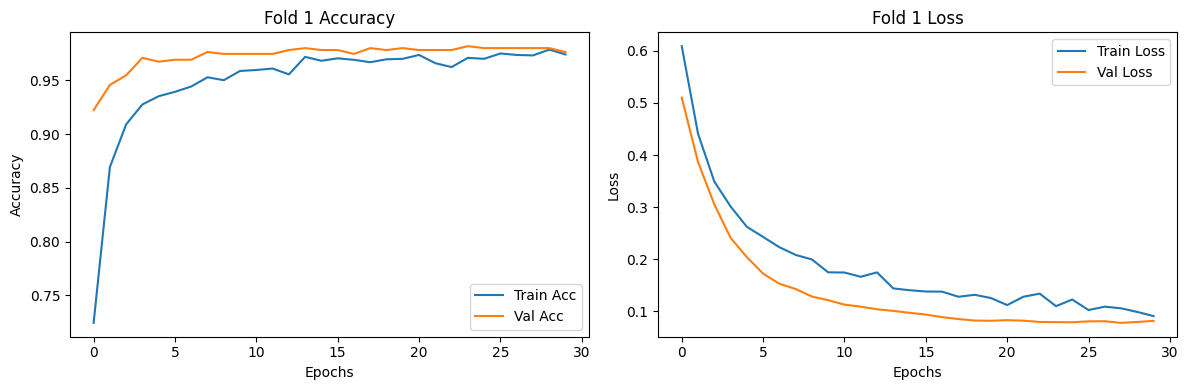

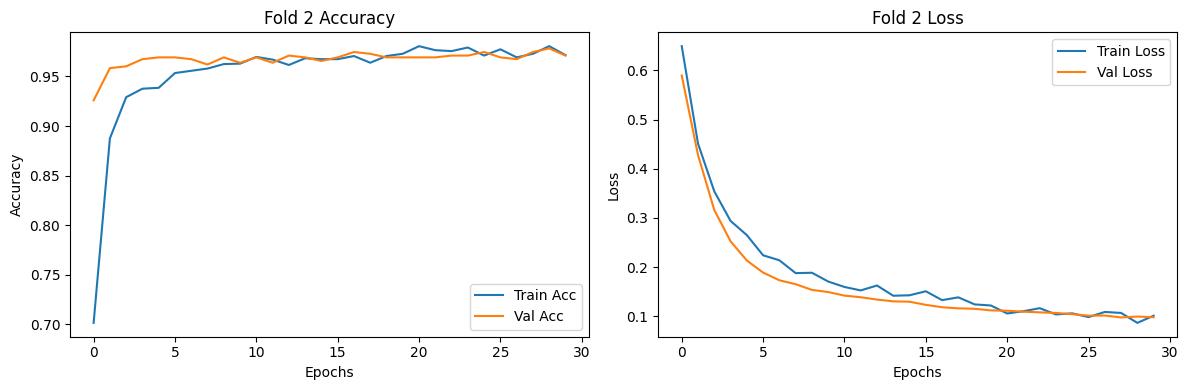

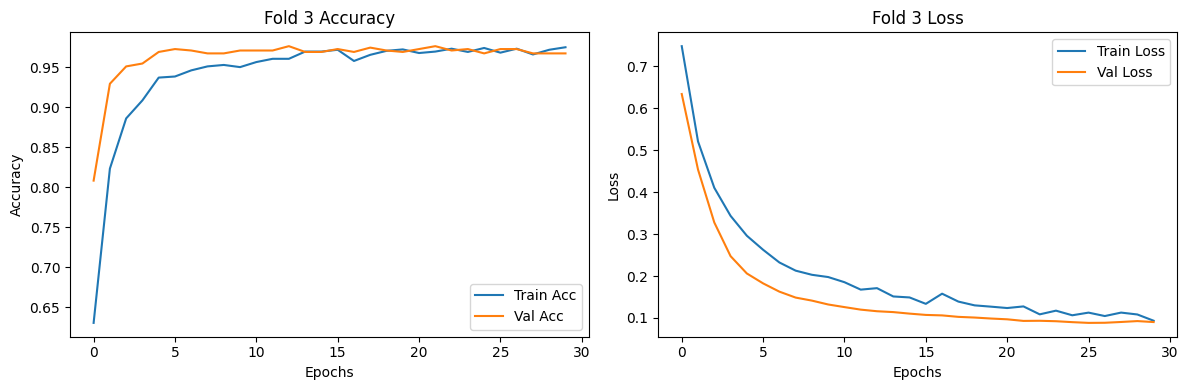

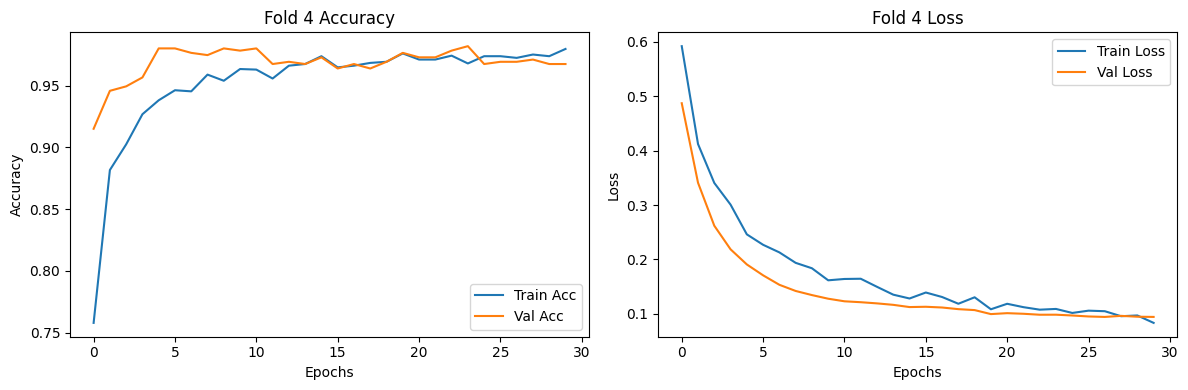

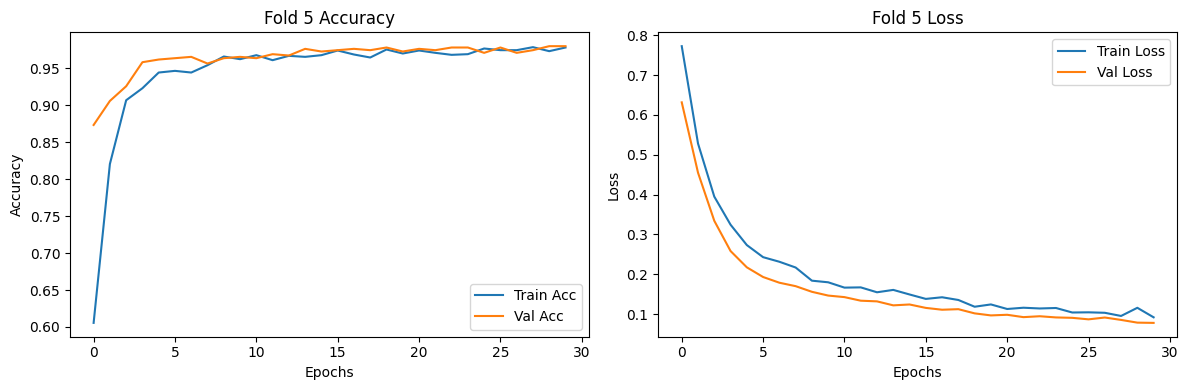


📊 Average Cross-Validation Metrics:
Accuracy  : 0.9754 ± 0.0042
Precision : 0.9825 ± 0.0051
Recall    : 0.9682 ± 0.0113
F1        : 0.9752 ± 0.0044
Auc       : 0.9971 ± 0.0012


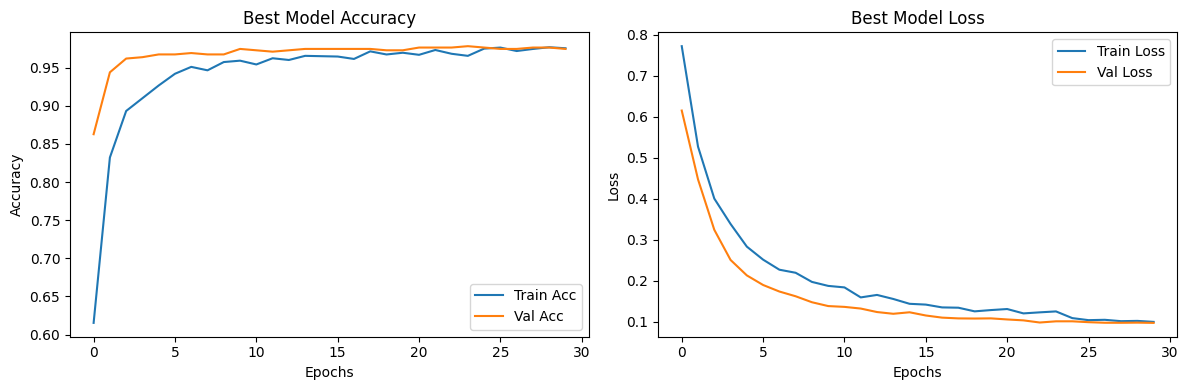

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step

✅ Final Evaluation on Test Set:
Accuracy : 0.9754
Precision: 0.9824
Recall   : 0.9682
F1 Score : 0.9753
AUC      : 0.9979


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Activation, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import keras_tuner as kt

# Load dataset
df = pd.read_csv("BotnetFull.csv")
df.columns = df.columns.str.replace('\n', '').str.strip()
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Train-test split
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Feature selection
rf = RandomForestClassifier()
selector = SelectFromModel(rf)
selector.fit(X_train_full, y_train_full)
X_train_selected = selector.transform(X_train_full)
X_test_selected = selector.transform(X_test)

print(f"✅ Features before selection: {X.shape[1]}")
print(f"✅ Features after selection : {X_train_selected.shape[1]}")

# Model builder
def build_model(hp):
    model = Sequential()
    model.add(Dense(
        hp.Int('units_0', 16, 64, step=16),
        input_shape=(X_train_selected.shape[1],),
        use_bias=False,
        kernel_regularizer=l2(hp.Float('l2_reg_0', 1e-4, 1e-2, sampling='log'))
    ))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dropout(hp.Float('dropout_0', 0.2, 0.3, step=0.1)))

    for i in range(hp.Int('num_layers', 1, 2)):
        model.add(Dense(
            hp.Int(f'units_{i+1}', 8, 32, step=8),
            use_bias=False,
            kernel_regularizer=l2(hp.Float(f'l2_reg_{i+1}', 1e-4, 1e-2, sampling='log'))
        ))
        model.add(BatchNormalization())
        model.add(Activation('relu'))
        model.add(Dropout(hp.Float(f'dropout_{i+1}', 0.3, 0.4, step=0.1)))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=hp.Choice('optimizer', ['adam']),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# Tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,
    overwrite=True,
    directory='botnet_tune',
    project_name='botnet_model'
)

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=0)

# Tune
tuner.search(X_train_selected, y_train_full, epochs=20, validation_split=0.2, callbacks=[early_stop, reduce_lr], verbose=1)
best_hp = tuner.get_best_hyperparameters(1)[0]
best_model = tuner.hypermodel.build(best_hp)

# Cross-validation evaluation
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
histories = []
metrics_per_fold = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train_selected, y_train_full)):
    print(f"\n🔁 Fold {fold+1}")
    X_train_cv, X_val_cv = X_train_selected[train_idx], X_train_selected[val_idx]
    y_train_cv, y_val_cv = y_train_full.iloc[train_idx], y_train_full.iloc[val_idx]

    model = tuner.hypermodel.build(best_hp)
    history = model.fit(
        X_train_cv, y_train_cv,
        validation_data=(X_val_cv, y_val_cv),
        epochs=30,
        batch_size=32,
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )
    histories.append(history)

    y_val_pred = model.predict(X_val_cv).ravel()
    y_val_pred_labels = (y_val_pred > 0.5).astype(int)

    metrics_per_fold.append({
        'accuracy': accuracy_score(y_val_cv, y_val_pred_labels),
        'precision': precision_score(y_val_cv, y_val_pred_labels),
        'recall': recall_score(y_val_cv, y_val_pred_labels),
        'f1': f1_score(y_val_cv, y_val_pred_labels),
        'auc': roc_auc_score(y_val_cv, y_val_pred)
    })

# Plot accuracy/loss for each fold
for i, history in enumerate(histories):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(f'Fold {i+1} Accuracy')
    plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'Fold {i+1} Loss')
    plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend()
    plt.tight_layout()
    plt.show()

# Average CV metrics
print("\n📊 Average Cross-Validation Metrics:")
for metric in ['accuracy', 'precision', 'recall', 'f1', 'auc']:
    values = [m[metric] for m in metrics_per_fold]
    print(f"{metric.capitalize():<10}: {np.mean(values):.4f} ± {np.std(values):.4f}")

# Final training on full data (best model)
final_history = best_model.fit(
    X_train_selected, y_train_full,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=0
)

# Plot best model training vs validation
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(final_history.history['accuracy'], label='Train Acc')
plt.plot(final_history.history['val_accuracy'], label='Val Acc')
plt.title('Best Model Accuracy'); plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(final_history.history['loss'], label='Train Loss')
plt.plot(final_history.history['val_loss'], label='Val Loss')
plt.title('Best Model Loss'); plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend()
plt.tight_layout()
plt.show()

# Final test evaluation
y_test_pred = best_model.predict(X_test_selected).ravel()
y_test_labels = (y_test_pred > 0.5).astype(int)

print("\n✅ Final Evaluation on Test Set:")
print(f"Accuracy : {accuracy_score(y_test, y_test_labels):.4f}")
print(f"Precision: {precision_score(y_test, y_test_labels):.4f}")
print(f"Recall   : {recall_score(y_test, y_test_labels):.4f}")
print(f"F1 Score : {f1_score(y_test, y_test_labels):.4f}")
print(f"AUC      : {roc_auc_score(y_test, y_test_pred):.4f}")


Trial 20 Complete [00h 00m 33s]
val_accuracy: 0.9819494485855103

Best val_accuracy So Far: 0.9819494485855103
Total elapsed time: 00h 07m 16s

🔁 Fold 1


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


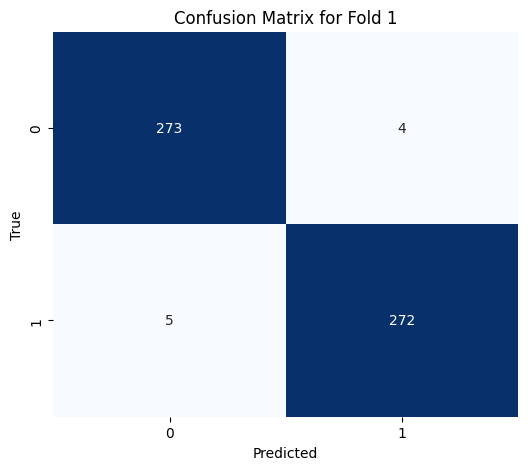

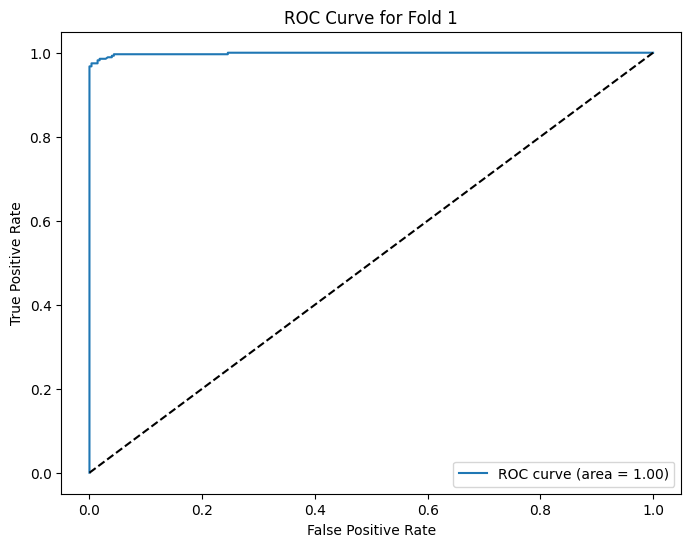


🔁 Fold 2


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


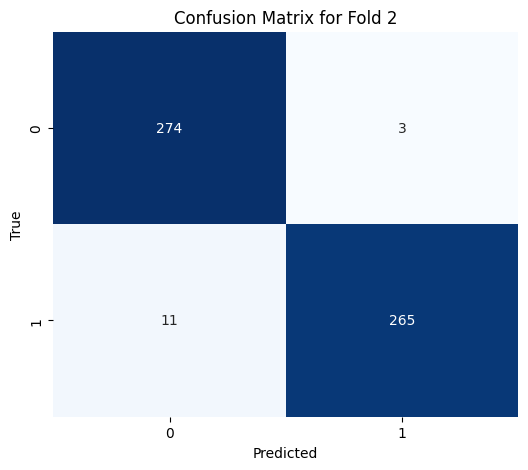

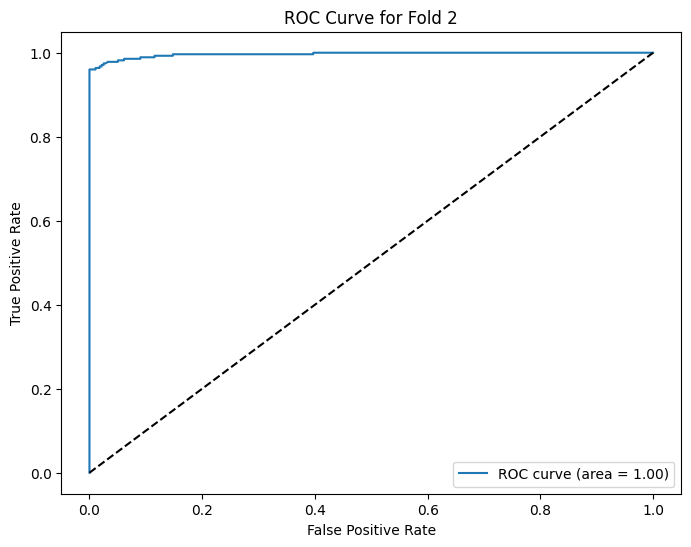


🔁 Fold 3


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


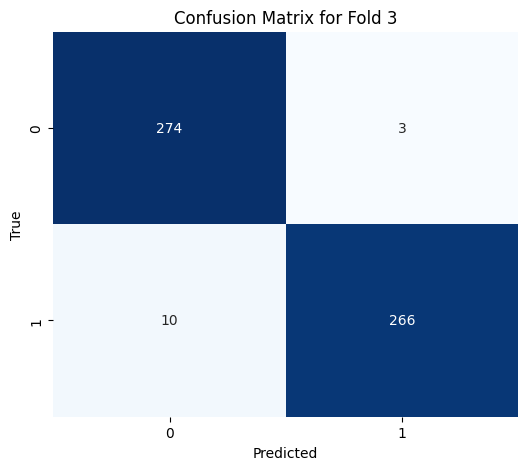

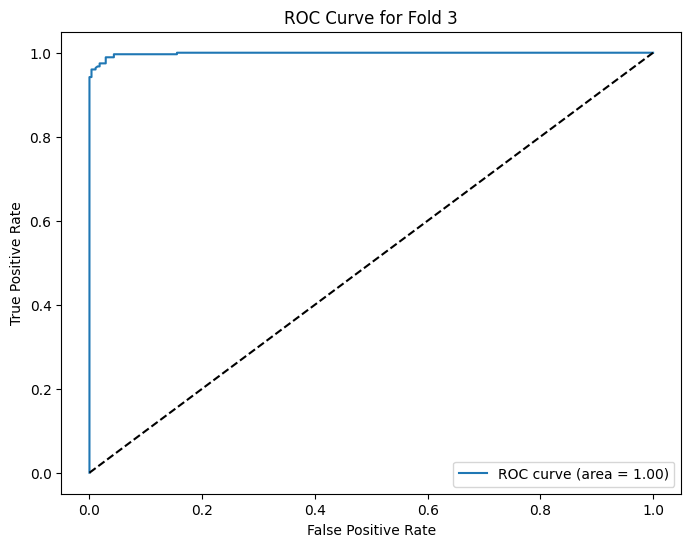


🔁 Fold 4


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


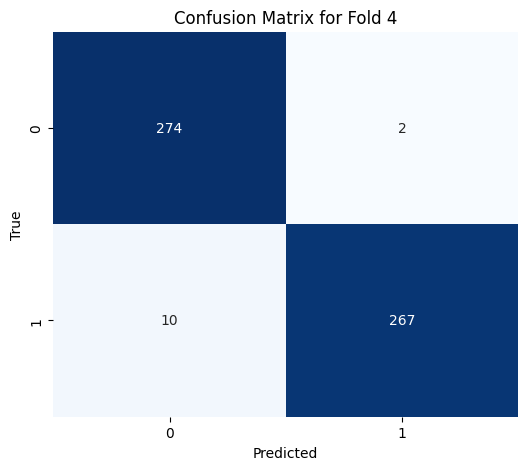

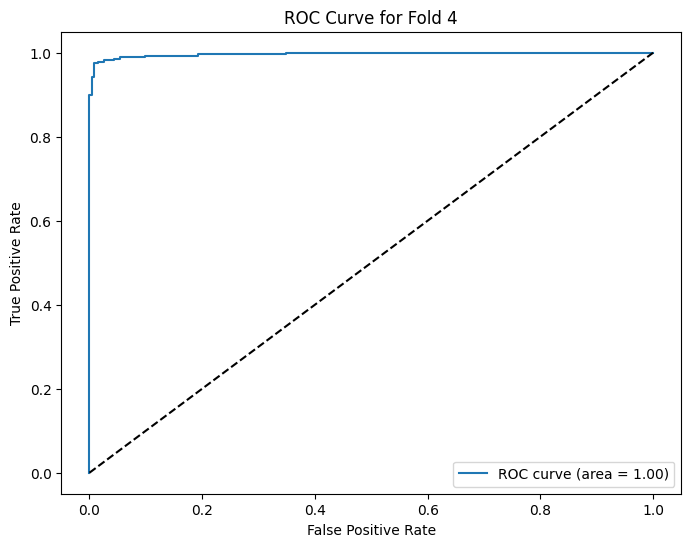


🔁 Fold 5


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


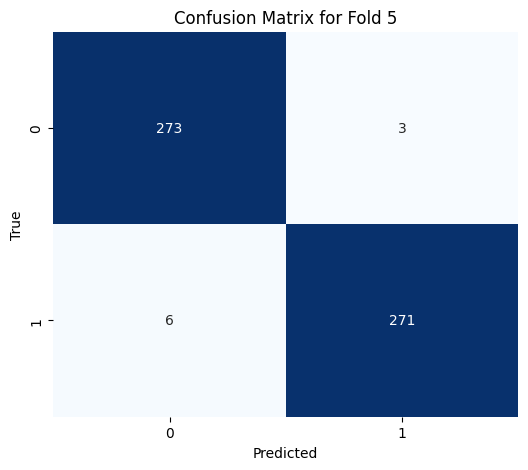

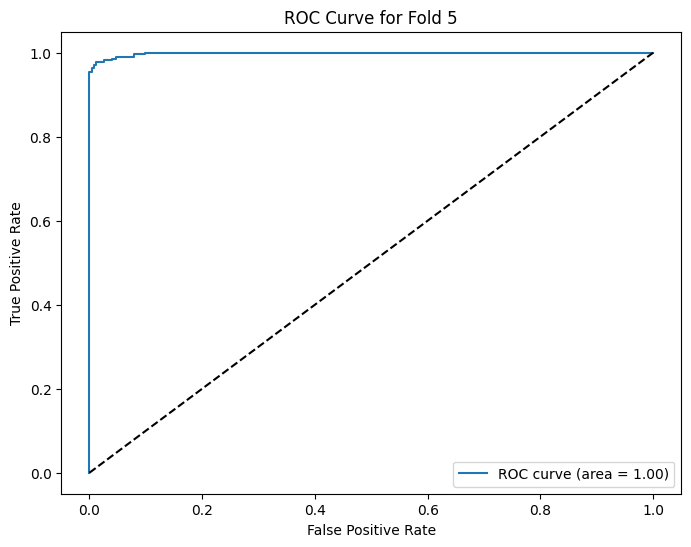

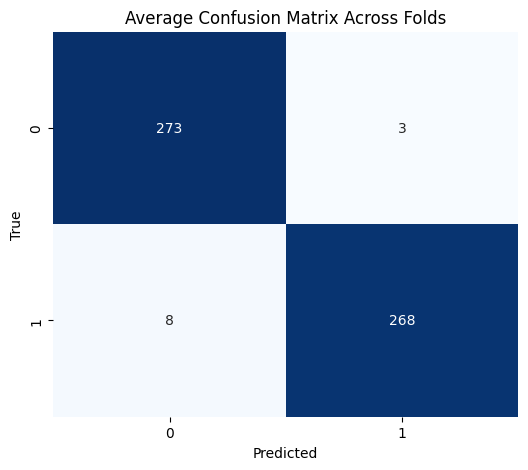


📊 Average Cross-Validation Metrics:
Accuracy  : 0.9794 ± 0.0037
Precision : 0.9890 ± 0.0022
Recall    : 0.9696 ± 0.0088
F1        : 0.9792 ± 0.0039
Auc       : 0.9977 ± 0.0009


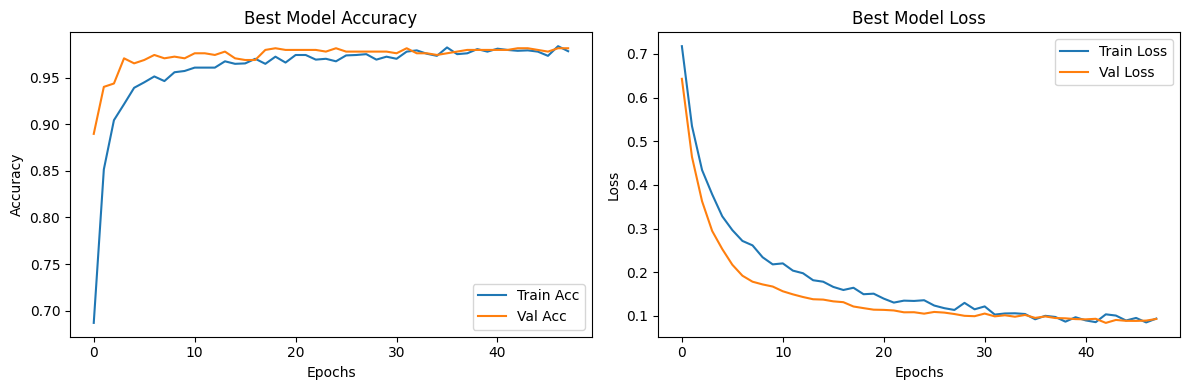

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step

✅ Final Evaluation on Test Set:
Accuracy : 0.9769
Precision: 0.9882
Recall   : 0.9653
F1 Score : 0.9766
AUC      : 0.9976


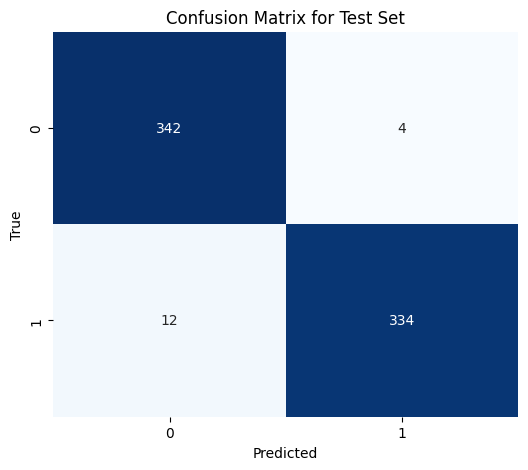

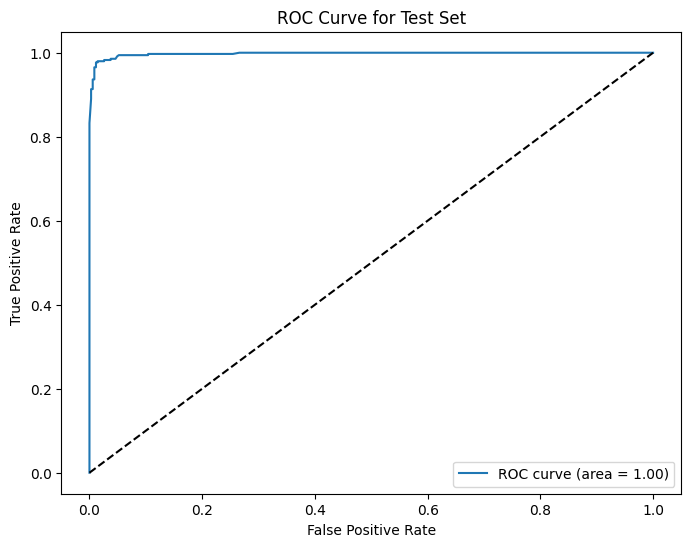

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Activation, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import keras_tuner as kt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

# Load dataset
df = pd.read_csv("BotnetFull.csv")
df.columns = df.columns.str.replace('\n', '').str.strip()
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Train-test split
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Feature selection
rf = RandomForestClassifier()
selector = SelectFromModel(rf)
selector.fit(X_train_full, y_train_full)
X_train_selected = selector.transform(X_train_full)
X_test_selected = selector.transform(X_test)

print(f"✅ Features before selection: {X.shape[1]}")
print(f"✅ Features after selection : {X_train_selected.shape[1]}")

# Model builder
def build_model(hp):
    model = Sequential()
    model.add(Dense(
        hp.Int('units_0', 16, 64, step=16),
        input_shape=(X_train_selected.shape[1],),
        use_bias=False,
        kernel_regularizer=l2(hp.Float('l2_reg_0', 1e-4, 1e-2, sampling='log'))
    ))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dropout(hp.Float('dropout_0', 0.2, 0.3, step=0.1)))

    for i in range(hp.Int('num_layers', 1, 2)):
        model.add(Dense(
            hp.Int(f'units_{i+1}', 8, 32, step=8),
            use_bias=False,
            kernel_regularizer=l2(hp.Float(f'l2_reg_{i+1}', 1e-4, 1e-2, sampling='log'))
        ))
        model.add(BatchNormalization())
        model.add(Activation('relu'))
        model.add(Dropout(hp.Float(f'dropout_{i+1}', 0.3, 0.4, step=0.1)))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=hp.Choice('optimizer', ['adam']),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# Tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=20,
    overwrite=True,
    directory='botnet_tune',
    project_name='botnet_model'
)

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=0)

# Tune
tuner.search(X_train_selected, y_train_full, epochs=100, validation_split=0.2, callbacks=[early_stop, reduce_lr], verbose=1)
best_hp = tuner.get_best_hyperparameters(1)[0]
best_model = tuner.hypermodel.build(best_hp)

# Cross-validation evaluation
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
histories = []
metrics_per_fold = []
confusion_matrices = []
roc_auc_per_fold = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train_selected, y_train_full)):
    print(f"\n🔁 Fold {fold+1}")
    X_train_cv, X_val_cv = X_train_selected[train_idx], X_train_selected[val_idx]
    y_train_cv, y_val_cv = y_train_full.iloc[train_idx], y_train_full.iloc[val_idx]

    model = tuner.hypermodel.build(best_hp)
    history = model.fit(
        X_train_cv, y_train_cv,
        validation_data=(X_val_cv, y_val_cv),
        epochs=30,
        batch_size=32,
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )
    histories.append(history)

    y_val_pred = model.predict(X_val_cv).ravel()
    y_val_pred_labels = (y_val_pred > 0.5).astype(int)

    # Confusion matrix
    cm = confusion_matrix(y_val_cv, y_val_pred_labels)
    confusion_matrices.append(cm)

    # Metrics
    metrics_per_fold.append({
        'accuracy': accuracy_score(y_val_cv, y_val_pred_labels),
        'precision': precision_score(y_val_cv, y_val_pred_labels),
        'recall': recall_score(y_val_cv, y_val_pred_labels),
        'f1': f1_score(y_val_cv, y_val_pred_labels),
        'auc': roc_auc_score(y_val_cv, y_val_pred)
    })

    # ROC curve
    fpr, tpr, _ = roc_curve(y_val_cv, y_val_pred)
    roc_auc = auc(fpr, tpr)
    roc_auc_per_fold.append(roc_auc)

    # Plot confusion matrix for each fold
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', cbar=False, xticklabels=[0, 1], yticklabels=[0, 1])
    plt.title(f'Confusion Matrix for Fold {fold+1}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    # Plot ROC curve for each fold
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'ROC Curve for Fold {fold+1}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.show()

# Plot average confusion matrix
avg_cm = np.mean(confusion_matrices, axis=0).astype(int)
plt.figure(figsize=(6, 5))
sns.heatmap(avg_cm, annot=True, fmt="d", cmap='Blues', cbar=False, xticklabels=[0, 1], yticklabels=[0, 1])
plt.title('Average Confusion Matrix Across Folds')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Average CV metrics
print("\n📊 Average Cross-Validation Metrics:")
for metric in ['accuracy', 'precision', 'recall', 'f1', 'auc']:
    values = [m[metric] for m in metrics_per_fold]
    print(f"{metric.capitalize():<10}: {np.mean(values):.4f} ± {np.std(values):.4f}")

# Final training on full data (best model)
final_history = best_model.fit(
    X_train_selected, y_train_full,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=0
)

# Plot best model training vs validation
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(final_history.history['accuracy'], label='Train Acc')
plt.plot(final_history.history['val_accuracy'], label='Val Acc')
plt.title('Best Model Accuracy'); plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(final_history.history['loss'], label='Train Loss')
plt.plot(final_history.history['val_loss'], label='Val Loss')
plt.title('Best Model Loss'); plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend()
plt.tight_layout()
plt.show()

# Final test evaluation
y_test_pred = best_model.predict(X_test_selected).ravel()
y_test_labels = (y_test_pred > 0.5).astype(int)

print("\n✅ Final Evaluation on Test Set:")
print(f"Accuracy : {accuracy_score(y_test, y_test_labels):.4f}")
print(f"Precision: {precision_score(y_test, y_test_labels):.4f}")
print(f"Recall   : {recall_score(y_test, y_test_labels):.4f}")
print(f"F1 Score : {f1_score(y_test, y_test_labels):.4f}")
print(f"AUC      : {roc_auc_score(y_test, y_test_pred):.4f}")

# Confusion Matrix for Test Set
cm_test = confusion_matrix(y_test, y_test_labels)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_test, annot=True, fmt="d", cmap='Blues', cbar=False, xticklabels=[0, 1], yticklabels=[0, 1])
plt.title('Confusion Matrix for Test Set')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# ROC Curve for Test Set
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_pred)
roc_auc_test = auc(fpr_test, tpr_test)
plt.figure(figsize=(8, 6))
plt.plot(fpr_test, tpr_test, label=f'ROC curve (area = {roc_auc_test:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve for Test Set')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()
